In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
import matplotlib.pyplot as plt

In [263]:
sys.path.append(os.path.abspath("../.."))
sys.path

['/opt/homebrew/Caskroom/miniconda/base/envs/spark/lib/python311.zip',
 '/opt/homebrew/Caskroom/miniconda/base/envs/spark/lib/python3.11',
 '/opt/homebrew/Caskroom/miniconda/base/envs/spark/lib/python3.11/lib-dynload',
 '',
 '/opt/homebrew/Caskroom/miniconda/base/envs/spark/lib/python3.11/site-packages',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project',
 '/Users/gauravrathore/Desktop/churn-prediction-project']

In [264]:
from src import utils

In [265]:
pd.set_option('display.max_columns', None)

In [266]:
df = pd.read_csv('../../data/raw/emails.csv')

/var/folders/47/spc9kf0x5xngx2jj19_8vgj00000gn/T/ipykernel_43745/496971227.py:1: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/raw/emails.csv')


In [267]:
df.head()

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,No,No,Not Discussed,No,Yes,1,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,No,Not Discussed,No,Accredited,No,Yes,1,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,No,Yes,No,Accredited,No,No,0,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,Yes,Yes,No,Accredited,Yes,Yes,3,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,No,Yes,No,Accredited,No,No,0,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


In [268]:
df.shape

(123389, 27)

### convert column names to snakecase

In [269]:
df = utils.convert_columns_to_snake_case(df)

### Identifying numerical and categorical data

In [270]:
df.dtypes

co_ref                                  object
time_to_renewal                         object
crm_accreditation_completed             object
crm_timely_completion                   object
crm_progress_towards_accreditation      object
crm_delays_in_accreditation             object
crm_contractor_suggested_leave          object
crm_contractor_engagement               object
crm_contractor_sentiment                object
crm_contractor_sentiment_score          object
crm_dts_or_ssip_mentioned               object
crm_customer_payment_intention          object
crm_competitors_mentioned               object
crm_membership_level                    object
crm_platform_issues_raised              object
crm_agent_chased_contractor             object
crm_agent_chase_count                   object
crm_accreditation_issues                object
crm_membership_overdue                  object
crm_auto_renewal_status                 object
crm_dissatisified_with_renewal_price    object
crm_customer_

In [271]:
df.nunique()

co_ref                                  37964
time_to_renewal                             4
crm_accreditation_completed                 3
crm_timely_completion                       3
crm_progress_towards_accreditation          3
crm_delays_in_accreditation                18
crm_contractor_suggested_leave              3
crm_contractor_engagement                  28
crm_contractor_sentiment                   12
crm_contractor_sentiment_score             52
crm_dts_or_ssip_mentioned                   9
crm_customer_payment_intention              6
crm_competitors_mentioned                   5
crm_membership_level                       57
crm_platform_issues_raised                  3
crm_agent_chased_contractor                 3
crm_agent_chase_count                     114
crm_accreditation_issues                    3
crm_membership_overdue                     53
crm_auto_renewal_status                    15
crm_dissatisified_with_renewal_price        6
crm_customer_complained           

In [272]:
df['time_to_renewal'].value_counts()

time_to_renewal
prior_year     40022
14_out         32493
45_out         28008
pre_renewal    22866
Name: count, dtype: int64

In [273]:
df['time_to_renewal'].isnull().sum()

np.int64(0)

### in column 'time_to_renewal' we can find pre_renewal category and filter out data which is relevant to our use case

In [274]:
df = df[df['time_to_renewal'] == 'pre_renewal']

In [275]:
df.head()

,co_ref,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,No,No,Not Discussed,No,Yes,1,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,No,Yes,No,Accredited,No,No,0,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026
6,SB4066,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,No,Yes,Not Discussed,Not Discussed,Not Discussed,Yes,3,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2026
7,YK0304,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Yes,No,0,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,Yes,Not Discussed,2025
8,HH3570,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,Yes,Yes,No,Accredited,No,Yes,1,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025


In [276]:
df.shape

(22866, 27)

### check for duplicates

In [277]:
df.duplicated().sum()

np.int64(0)

### Most of the columns contain categorical data and mixed data such as numerical and string. 'Not Discussed' is used in place of nulls

In [278]:
for col in df.columns:
    print(df[col].value_counts())
    print('nulls: ', df[col].isnull().sum())
    print('-' * 100)


co_ref
JM8979    3
QE7976    3
NU6835    2
KI4313    2
XT9837    2
         ..
GM7451    1
RW8178    1
IX3469    1
QW9278    1
TD7281    1
Name: count, Length: 21362, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
time_to_renewal
pre_renewal    22866
Name: count, dtype: int64
nulls:  0
----------------------------------------------------------------------------------------------------
crm_accreditation_completed
Not Discussed    10722
No                6742
Yes               2247
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_timely_completion
Not Discussed    17824
No                1474
Yes                413
Name: count, dtype: int64
nulls:  3155
----------------------------------------------------------------------------------------------------
crm_progress_towards_accreditation
Not Discussed    13790
Yes      

In [279]:
df.dtypes

co_ref                                  object
time_to_renewal                         object
crm_accreditation_completed             object
crm_timely_completion                   object
crm_progress_towards_accreditation      object
crm_delays_in_accreditation             object
crm_contractor_suggested_leave          object
crm_contractor_engagement               object
crm_contractor_sentiment                object
crm_contractor_sentiment_score          object
crm_dts_or_ssip_mentioned               object
crm_customer_payment_intention          object
crm_competitors_mentioned               object
crm_membership_level                    object
crm_platform_issues_raised              object
crm_agent_chased_contractor             object
crm_agent_chase_count                   object
crm_accreditation_issues                object
crm_membership_overdue                  object
crm_auto_renewal_status                 object
crm_dissatisified_with_renewal_price    object
crm_customer_

## handle numerical columns

In [280]:
numerical_cols = ['crm_contractor_sentiment_score', 'crm_agent_chase_count']

In [281]:
df[numerical_cols].dtypes

crm_contractor_sentiment_score    object
crm_agent_chase_count             object
dtype: object

In [282]:
for col in numerical_cols:
    df[col] = pd.to_numeric(
        df[col], errors='coerce'
    )

In [283]:
for col in numerical_cols:
    print(col)
    print(df[col].unique())
    print('-' * 100)

crm_contractor_sentiment_score
[ 50.   80.    nan  40.   20.   30.   60.   84.    0.   90.  100.   16.
  91.   48.   55.   70.   31.   98.   25.5  96. ]
----------------------------------------------------------------------------------------------------
crm_agent_chase_count
[ 1.  0.  3.  2.  5.  6. nan  4. 11. 10. 13.  7.  8.]
----------------------------------------------------------------------------------------------------


### cleaning crm_contractor_sentiment_score

In [284]:
df['crm_contractor_sentiment_score'].value_counts()

crm_contractor_sentiment_score
50.0     8609
80.0     1449
20.0      811
90.0      577
0.0       282
30.0      238
100.0     225
40.0      168
84.0        1
60.0        1
16.0        1
91.0        1
48.0        1
55.0        1
70.0        1
31.0        1
98.0        1
25.5        1
96.0        1
Name: count, dtype: int64

In [285]:
df['crm_contractor_sentiment_score'].isnull().sum()

np.int64(10496)

In [286]:
df["crm_contractor_sentiment_score"].isna().mean() * 100

np.float64(45.90221289250416)

In [287]:
df['crm_contractor_sentiment_score'].skew()

np.float64(0.1373348999690788)

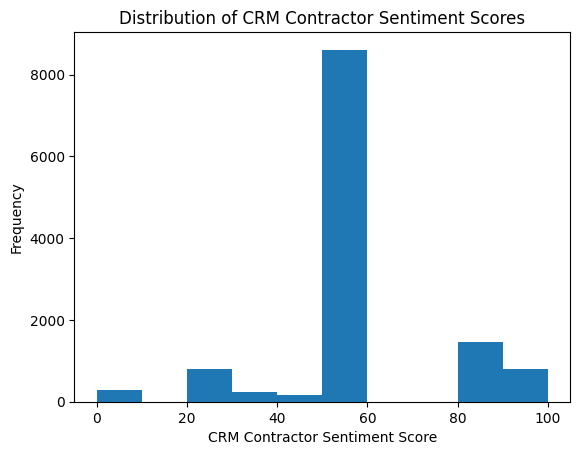

In [288]:
plt.hist(df['crm_contractor_sentiment_score'], bins=10)
plt.xlabel('CRM Contractor Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of CRM Contractor Sentiment Scores')
plt.show()

### we cannot fill this directly with mean, median or mode as all of them will be 50 due to highest
This completely destroys the discriminative power of this feature.

In [289]:
df['crm_contractor_sentiment'].value_counts()

crm_contractor_sentiment
Neutral                                  8612
Not Discussed                            7337
Satisfied                                2254
Dissatisfied                             1503
Yes                                         3
Initially Dissatisfied, later Neutral       1
No                                          1
Name: count, dtype: int64

In [290]:
def clean_sentiment(val):
    if pd.isna(val):
        return "Unknown"
    
    val = str(val).lower().strip()
    
    # handle not discussed
    if "not" in val:
        return "Unknown"
    
    # handle mixed sentiment (very important)
    if "dissatisfied" in val and "neutral" in val:
        return "neutral"   # final state matters more
    
    # normal cases
    if "dissatisfied" in val:
        return "dissatisfied"
    elif "satisfied" in val:
        return "satisfied"
    
    
    return "neutral"

df['crm_contractor_sentiment'] = df['crm_contractor_sentiment'].apply(clean_sentiment)

In [291]:
df['crm_contractor_sentiment'].value_counts()

crm_contractor_sentiment
Unknown         10492
neutral          8617
satisfied        2254
dissatisfied     1503
Name: count, dtype: int64

we will add a missing indicator for null values and fill with -1 (outside 0-100 range), this helps model differentiate these values without compromizing on raws

In [292]:
# missing indicator
df["sentiment_score_missing"] = df["crm_contractor_sentiment_score"].isna().astype(int)

# Fill "Not Discussed" group with a DISTINCT sentinel value
# Use a value OUTSIDE the normal 0-100 range, like -1
# This tells the model "this is a different category"
df["crm_contractor_sentiment_score"] = df["crm_contractor_sentiment_score"].fillna(-1)


In [293]:
df.shape

(22866, 28)

In [294]:
print(df['crm_contractor_sentiment_score'].isnull().sum())

0


In [295]:
df['crm_contractor_sentiment_score'].value_counts()

crm_contractor_sentiment_score
-1.0      10496
 50.0      8609
 80.0      1449
 20.0       811
 90.0       577
 0.0        282
 30.0       238
 100.0      225
 40.0       168
 84.0         1
 60.0         1
 16.0         1
 91.0         1
 48.0         1
 55.0         1
 70.0         1
 31.0         1
 98.0         1
 25.5         1
 96.0         1
Name: count, dtype: int64

## crm_agent_chase_count

In [296]:
print(df['crm_agent_chase_count'].unique())

[ 1.  0.  3.  2.  5.  6. nan  4. 11. 10. 13.  7.  8.]


In [297]:
df['crm_agent_chase_count'].value_counts()

crm_agent_chase_count
0.0     8359
1.0     8125
2.0     3818
3.0      824
4.0      106
5.0       31
6.0        9
7.0        5
10.0       2
11.0       1
13.0       1
8.0        1
Name: count, dtype: int64

In [298]:
print(df['crm_agent_chase_count'].isnull().sum())

1584


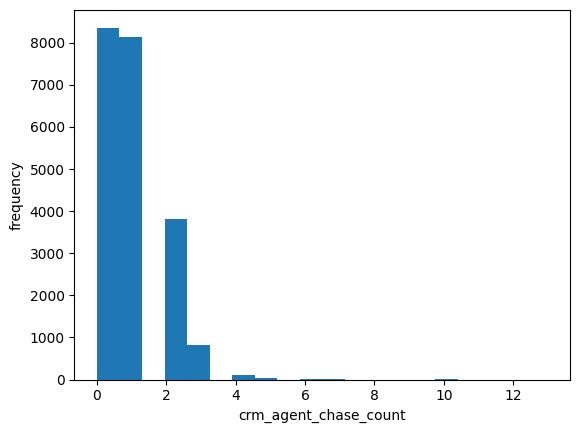

In [299]:
plt.hist(df['crm_agent_chase_count'], bins=20)
plt.xlabel('crm_agent_chase_count')
plt.ylabel('frequency')
plt.show()

In [300]:
df['crm_agent_chase_count'].skew()

np.float64(1.2204974752783757)

In [301]:
df['crm_agent_chase_count'].median()

np.float64(1.0)

In [302]:
# use median to fill
df['crm_agent_chase_count'] = df['crm_agent_chase_count'].fillna(
    df['crm_agent_chase_count'].median()
)

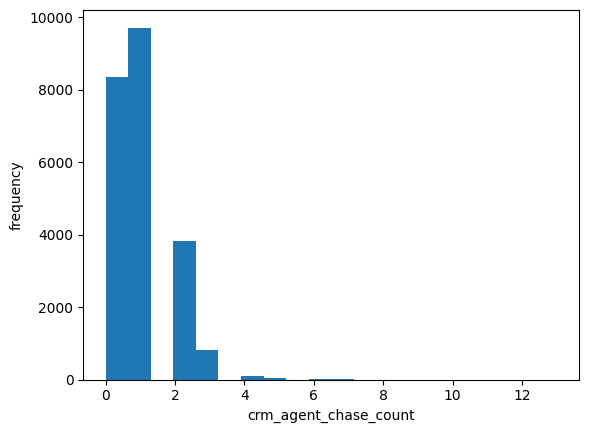

In [303]:
plt.hist(df['crm_agent_chase_count'], bins=20)
plt.xlabel('crm_agent_chase_count')
plt.ylabel('frequency')
plt.show()

### handling categorical features

In [304]:
for col in df.columns:
    print(df[col].value_counts())
    print(df[col].isnull().sum())

co_ref
JM8979    3
QE7976    3
NU6835    2
KI4313    2
XT9837    2
         ..
GM7451    1
RW8178    1
IX3469    1
QW9278    1
TD7281    1
Name: count, Length: 21362, dtype: int64
0
time_to_renewal
pre_renewal    22866
Name: count, dtype: int64
0
crm_accreditation_completed
Not Discussed    10722
No                6742
Yes               2247
Name: count, dtype: int64
3155
crm_timely_completion
Not Discussed    17824
No                1474
Yes                413
Name: count, dtype: int64
3155
crm_progress_towards_accreditation
Not Discussed    13790
Yes               5343
No                 578
Name: count, dtype: int64
3155
crm_delays_in_accreditation
No                                                                                                                            14986
Yes                                                                                                                            4464
Not Discussed                                                               

In [305]:
categorical_cols = []

for col in df.columns:
    if col not in numerical_cols:
        categorical_cols.append(col)

## GROUP A: Clean columns — just fill NaN with "Unknown"

In [306]:
group_a_cols = [
    'crm_accreditation_completed',
    'crm_timely_completion',
    'crm_progress_towards_accreditation',
    'crm_contractor_suggested_leave',
    'crm_customer_payment_intention',
    'crm_competitors_mentioned',
    'crm_platform_issues_raised',
    'crm_agent_chased_contractor',
    'crm_accreditation_issues',
]

In [307]:
for col in group_a_cols:
    df[col] = df[col].fillna('Unknown')

In [308]:
for col in group_a_cols:
    print(df[col].value_counts())
    print('-' * 100)

crm_accreditation_completed
Not Discussed    10722
No                6742
Unknown           3155
Yes               2247
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
crm_timely_completion
Not Discussed    17824
Unknown           3155
No                1474
Yes                413
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
crm_progress_towards_accreditation
Not Discussed    13790
Yes               5343
Unknown           3155
No                 578
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
crm_contractor_suggested_leave
No               14480
Unknown           3155
Not Discussed     2649
Yes               2582
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
crm_cust

### GROUP B: Columns with garbage text to clean

In [309]:
#crm_delays_in_accreditation 
def clean_delays(val):
    if pd.isna(val):
        return 'Not Discussed'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if 'not discussed' in val and 'yes' in val:
        return 'yes'  # "Not Discussed but potentially yes..."
    if val == 'not discussed':
        return 'Not Discussed'
    return 'Not Discussed'  # fallback

df['crm_delays_in_accreditation'] = df['crm_delays_in_accreditation'].apply(clean_delays)

In [310]:
df['crm_delays_in_accreditation'].value_counts()

crm_delays_in_accreditation
no               14986
yes               4466
Not Discussed     3414
Name: count, dtype: int64

### crm_contractor_engagement

In [311]:
def clean_engagement(val):
    if pd.isna(val):
        return 'Not Discussed'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    # All garbage text mentions dissatisfaction/loss of interest → not engaged
    return 'no'

df['crm_contractor_engagement'] = df['crm_contractor_engagement'].apply(clean_engagement)

In [312]:
df['crm_contractor_engagement'].value_counts()

crm_contractor_engagement
yes              12361
no                7346
Not Discussed     3159
Name: count, dtype: int64

###  crm_dts_or_ssip_mentioned (collapse to binary yes/no)

In [313]:
def clean_dts(val):
    if pd.isna(val):
        return 'no'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    # everything else (no, numbers, not discussed) → no
    return 'no'

df['crm_dts_or_ssip_mentioned'] = df['crm_dts_or_ssip_mentioned'].apply(clean_dts)

In [314]:
df['crm_dts_or_ssip_mentioned'].value_counts()

crm_dts_or_ssip_mentioned
no     18637
yes     4229
Name: count, dtype: int64

### crm_membership_overdue

In [315]:
def clean_overdue(val):
    if pd.isna(val):
        return 'Not Discussed'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    # "Almost expired" and all garbage text → yes
    return 'yes'

df['crm_membership_overdue'] = df['crm_membership_overdue'].apply(clean_overdue)

### crm_auto_renewal_status

In [316]:
df['crm_auto_renewal_status'].value_counts()

crm_auto_renewal_status
0                              13549
0                               6429
2                               1226
1                                140
Not Discussed                      3
 and employer's liability."        1
Name: count, dtype: int64

In [317]:

# --- crm_auto_renewal_status (convert to numeric int) ---
df['crm_auto_renewal_status'] = pd.to_numeric(
    df['crm_auto_renewal_status'], errors='coerce'
)
# Fill NaN with mode (0)
df['crm_auto_renewal_status'] = df['crm_auto_renewal_status'].fillna(0).astype(int)

In [318]:
df['crm_auto_renewal_status'].value_counts()

crm_auto_renewal_status
0    21500
2     1226
1      140
Name: count, dtype: int64

### crm_dissatisified_with_renewal_price

In [319]:
df['crm_dissatisified_with_renewal_price'].isnull().sum()

np.int64(1518)

In [320]:
def clean_dissatisfied_price(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val in ('no', '0'):
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    return 'Not Discussed'

df['crm_dissatisified_with_renewal_price'] = df['crm_dissatisified_with_renewal_price'].apply(clean_dissatisfied_price)

In [321]:
df['crm_dissatisified_with_renewal_price'].value_counts()

crm_dissatisified_with_renewal_price
Not Discussed    14649
no                5377
Unknown           1518
yes               1322
Name: count, dtype: int64


###  crm_customer_complained

In [322]:
def clean_complained(val):
    if pd.isna(val):
        return 'Not Discussed'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if 'not applicable' in val or 'not discussed' in val:
        return 'Not Discussed'
    # [Yes/No] and other ambiguous → no (majority class)
    return 'no'

df['crm_customer_complained'] = df['crm_customer_complained'].apply(clean_complained)

In [323]:
df['crm_customer_complained'].value_counts()

crm_customer_complained
no               19722
Not Discussed     1632
yes               1512
Name: count, dtype: int64

### crm_refund_mentioned (collapse to binary yes/no)

In [329]:
df['crm_refund_mentioned'].isnull().sum()

np.int64(1630)

In [330]:
def clean_refund(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    # everything else → no
    return 'no'
    
df['crm_refund_mentioned'] = df['crm_refund_mentioned'].apply(clean_refund)

In [331]:
df['crm_refund_mentioned'].value_counts()

crm_refund_mentioned
no         20935
Unknown     1630
yes          301
Name: count, dtype: int64

### crm_negative_customer_experience

In [332]:
df['crm_negative_customer_experience'].isnull().sum()

np.int64(1630)

In [334]:
df['crm_negative_customer_experience'].value_counts()

crm_negative_customer_experience
No                                                       11959
Not Discussed                                             5560
Yes                                                       3714
[Yes/No/Not Discussed]                                       1
 causing them to lose work."                                 1
Not applicable (there is no email content to analyze)        1
Name: count, dtype: int64

In [335]:
def clean_negative_exp(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    if 'not applicable' in val or '[' in val:
        return 'Not Discussed'
    # text describing negative experience → yes
    return 'yes'

df['crm_negative_customer_experience'] = df['crm_negative_customer_experience'].apply(clean_negative_exp)


In [336]:
df['crm_negative_customer_experience'].value_counts()

crm_negative_customer_experience
no               11959
Not Discussed     5562
yes               3715
Unknown           1630
Name: count, dtype: int64

### crm_dissatisfaction_with_support

In [337]:
df['crm_dissatisfaction_with_support'].isnull().sum()

np.int64(1630)

In [338]:
def clean_dissatisfaction_support(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    if 'not applicable' in val or '[' in val or 'invalid' in val:
        return 'Not Discussed'
    # all text mentioning negative experience, frustration, dissatisfied → yes
    return 'yes'
df['crm_dissatisfaction_with_support'] = df['crm_dissatisfaction_with_support'].apply(clean_dissatisfaction_support)

In [339]:
df['crm_dissatisfaction_with_support'].value_counts()

crm_dissatisfaction_with_support
no               11628
Not Discussed     8086
Unknown           1630
yes               1522
Name: count, dtype: int64

### crm_financial_hardship_mentioned 

In [341]:
df['crm_financial_hardship_mentioned'].isnull().sum()

np.int64(1630)

In [344]:
df['crm_financial_hardship_mentioned'].value_counts()

crm_financial_hardship_mentioned
Not Discussed    15611
no                4305
Unknown           1630
yes               1320
Name: count, dtype: int64

In [342]:
def clean_financial(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'yes':
        return 'yes'
    if val == 'no':
        return 'no'
    if val == 'not discussed':
        return 'Not Discussed'
    if 'not applicable' in val or '[' in val or 'city is' in val:
        return 'Not Discussed'
    # frustration/payment issues → yes
    return 'yes'
    
df['crm_financial_hardship_mentioned'] = df['crm_financial_hardship_mentioned'].apply(clean_financial)

In [343]:
df['crm_financial_hardship_mentioned'].value_counts()

crm_financial_hardship_mentioned
Not Discussed    15611
no                4305
Unknown           1630
yes               1320
Name: count, dtype: int64

### GROUP C: crm_membership_level — consolidate categories

In [345]:
df['crm_membership_level'].value_counts()

crm_membership_level
Not Discussed                8374
Accredited                   7153
In progress                  5621
Members only                  101
Not Accredited                 70
Standard                        9
Membership (Standard)           5
Standard membership             3
Gold                            2
Standard membership level       2
Prem                            1
Accredited (Gold level)         1
Premier Band B                  1
Premier package                 1
Silver                          1
Premier Band C2                 1
Premier services                1
Express membership level        1
Name: count, dtype: int64

In [346]:
df['crm_membership_level'].isnull().sum()

np.int64(1518)

In [347]:
def clean_membership(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'not discussed':
        return 'Not Discussed'
    if val == 'accredited':
        return 'accredited'
    if val == 'in progress':
        return 'in_progress'
    if val in ('members only',):
        return 'members_only'
    if val in ('not accredited',):
        return 'not_accredited'
    if 'standard' in val or 'express' in val or 'membership' in val:
        return 'standard'
    if 'premier' in val or val == 'prem':
        return 'premier'
    if val in ('gold', 'silver', 'accredited (gold level)'):
        return 'accredited'
    return 'Not Discussed'  # fallback
    
df['crm_membership_level'] = df['crm_membership_level'].apply(clean_membership)

In [348]:
df['crm_membership_level'].value_counts()

crm_membership_level
Not Discussed     8374
accredited        7157
in_progress       5621
Unknown           1518
members_only       101
not_accredited      70
standard            20
premier              5
Name: count, dtype: int64

### VERIFICATION: Check all categorical columns are clean

In [349]:
categorical_cols = [
    'crm_accreditation_completed', 'crm_timely_completion',
    'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
    'crm_contractor_suggested_leave', 'crm_contractor_engagement',
    'crm_contractor_sentiment', 'crm_dts_or_ssip_mentioned',
    'crm_customer_payment_intention', 'crm_competitors_mentioned',
    'crm_membership_level', 'crm_platform_issues_raised',
    'crm_agent_chased_contractor', 'crm_accreditation_issues',
    'crm_membership_overdue', 'crm_dissatisified_with_renewal_price',
    'crm_customer_complained', 'crm_refund_mentioned',
    'crm_negative_customer_experience', 'crm_dissatisfaction_with_support',
    'crm_financial_hardship_mentioned',
]

In [350]:
print("=== POST-CLEANING VERIFICATION ===\n")
for col in categorical_cols:
    print(f"{col}")
    print(f"  unique: {df[col].nunique()}")
    print(f"  nulls:  {df[col].isnull().sum()}")
    print(f"  values: {df[col].value_counts().to_dict()}")
    print()
print(f"Final shape: {df.shape}")
print(f"Rows removed: 0")

=== POST-CLEANING VERIFICATION ===

crm_accreditation_completed
  unique: 4
  nulls:  0
  values: {'Not Discussed': 10722, 'No': 6742, 'Unknown': 3155, 'Yes': 2247}

crm_timely_completion
  unique: 4
  nulls:  0
  values: {'Not Discussed': 17824, 'Unknown': 3155, 'No': 1474, 'Yes': 413}

crm_progress_towards_accreditation
  unique: 4
  nulls:  0
  values: {'Not Discussed': 13790, 'Yes': 5343, 'Unknown': 3155, 'No': 578}

crm_delays_in_accreditation
  unique: 3
  nulls:  0
  values: {'no': 14986, 'yes': 4466, 'Not Discussed': 3414}

crm_contractor_suggested_leave
  unique: 4
  nulls:  0
  values: {'No': 14480, 'Unknown': 3155, 'Not Discussed': 2649, 'Yes': 2582}

crm_contractor_engagement
  unique: 3
  nulls:  0
  values: {'yes': 12361, 'no': 7346, 'Not Discussed': 3159}

crm_contractor_sentiment
  unique: 4
  nulls:  0
  values: {'Unknown': 10492, 'neutral': 8617, 'satisfied': 2254, 'dissatisfied': 1503}

crm_dts_or_ssip_mentioned
  unique: 2
  nulls:  0
  values: {'no': 18637, 'yes': 

In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22866 entries, 0 to 123351
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   co_ref                                22866 non-null  object 
 1   time_to_renewal                       22866 non-null  object 
 2   crm_accreditation_completed           22866 non-null  object 
 3   crm_timely_completion                 22866 non-null  object 
 4   crm_progress_towards_accreditation    22866 non-null  object 
 5   crm_delays_in_accreditation           22866 non-null  object 
 6   crm_contractor_suggested_leave        22866 non-null  object 
 7   crm_contractor_engagement             22866 non-null  object 
 8   crm_contractor_sentiment              22866 non-null  object 
 9   crm_contractor_sentiment_score        22866 non-null  float64
 10  crm_dts_or_ssip_mentioned             22866 non-null  object 
 11  crm_customer_paymen